## Northwind Database - SQL & Pandas Analysis

This notebook analyzes the Northwind sample database to answer key business questions: top-selling products, top customers by revenue, monthly sales trends, best-performing categories and customer purchase frequency. Each question is answered using SQL queries executed against the SQLite database, with results explored and visualized using Pandas.

In [16]:
import sqlite3
import pandas as pd
conn=sqlite3.connect('/content/northwind.db')
tables=pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';",conn)
print(tables)

                    name
0             Categories
1        sqlite_sequence
2   CustomerCustomerDemo
3   CustomerDemographics
4              Customers
5              Employees
6    EmployeeTerritories
7          Order Details
8                 Orders
9               Products
10               Regions
11              Shippers
12             Suppliers
13           Territories


In [17]:
print(pd.read_sql_query("PRAGMA table_info(Products);",conn))
print(pd.read_sql_query('PRAGMA table_info("Order Details");',conn))

   cid             name     type  notnull dflt_value  pk
0    0        ProductID  INTEGER        1       None   1
1    1      ProductName     TEXT        1       None   0
2    2       SupplierID  INTEGER        0       None   0
3    3       CategoryID  INTEGER        0       None   0
4    4  QuantityPerUnit     TEXT        0       None   0
5    5        UnitPrice  NUMERIC        0          0   0
6    6     UnitsInStock  INTEGER        0          0   0
7    7     UnitsOnOrder  INTEGER        0          0   0
8    8     ReorderLevel  INTEGER        0          0   0
9    9     Discontinued     TEXT        1        '0'   0
   cid       name     type  notnull dflt_value  pk
0    0    OrderID  INTEGER        1       None   1
1    1  ProductID  INTEGER        1       None   2
2    2  UnitPrice  NUMERIC        1          0   0
3    3   Quantity  INTEGER        1          1   0
4    4   Discount     REAL        1          0   0


Top 10 Selling Products

In [19]:
q1 = """
SELECT p.ProductName, SUM(od.Quantity) AS TotalQuantitySold
FROM "Order Details" od
JOIN Products p ON od.ProductID=p.ProductID
GROUP BY p.ProductName
ORDER BY TotalQuantitySold DESC
LIMIT 10;
"""
df1 = pd.read_sql_query(q1, conn)
df1

,ProductName,TotalQuantitySold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


Top 10 Customers by Revenue

In [21]:
q2 = """
SELECT c.CompanyName,ROUND(SUM(od.UnitPrice*od.Quantity*(1-od.Discount)),2)AS Revenue
FROM "Order Details" od
JOIN Orders o ON od.OrderID=o.OrderID
JOIN Customers c ON o.CustomerID=c.CustomerID
GROUP BY c.CompanyName
ORDER BY Revenue DESC
LIMIT 10;
"""
df2=pd.read_sql_query(q2,conn)
df2

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34


Monthly Sales Trends

In [22]:
q3 = """
SELECT strftime('%Y-%m',o.OrderDate)AS Month,
       ROUND(SUM(od.UnitPrice*od.Quantity*(1-od.Discount)),2)AS MonthlyRevenue
FROM Orders o
JOIN "Order Details" od ON o.OrderID=od.OrderID
GROUP BY Month
ORDER BY Month;
"""
df3=pd.read_sql_query(q3,conn)
df3

,Month,MonthlyRevenue
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


Best-Performing Categories

In [24]:
q4 = """
SELECT cat.CategoryName, ROUND(SUM(od.UnitPrice*od.Quantity*(1-od.Discount)),2)AS Revenue
FROM "Order Details" od
JOIN Products p ON od.ProductID=p.ProductID
JOIN Categories cat ON p.CategoryID=cat.CategoryID
GROUP BY cat.CategoryName
ORDER BY Revenue DESC;
"""
df4=pd.read_sql_query(q4,conn)
df4

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


Customer Purchase Frequency

In [25]:
q5 = """
SELECT c.CompanyName,COUNT(o.OrderID)AS NumberOfOrders
FROM Customers c
JOIN Orders o ON c.CustomerID=o.CustomerID
GROUP BY c.CompanyName
ORDER BY NumberOfOrders DESC
LIMIT 10;
"""
df5=pd.read_sql_query(q5,conn)
df5

,CompanyName,NumberOfOrders
0,IT,335
1,B's Beverages,210
2,Ricardo Adocicados,203
3,LILA-Supermercado,203
4,Gourmet Lanchonetes,202
5,Princesa Isabel Vinhos,200
6,Hungry Coyote Import Store,198
7,Tortuga Restaurante,197
8,Folies gourmandes,195
9,Ana Trujillo Emparedados y helados,195


In [10]:
df1.describe()

,TotalQuantitySold
count,10.000000
mean,204753.100000
std,820.692452
min,203667.000000
25%,204165.500000
50%,204582.000000
75%,205366.500000
max,206213.000000


<Axes: xlabel='ProductName'>

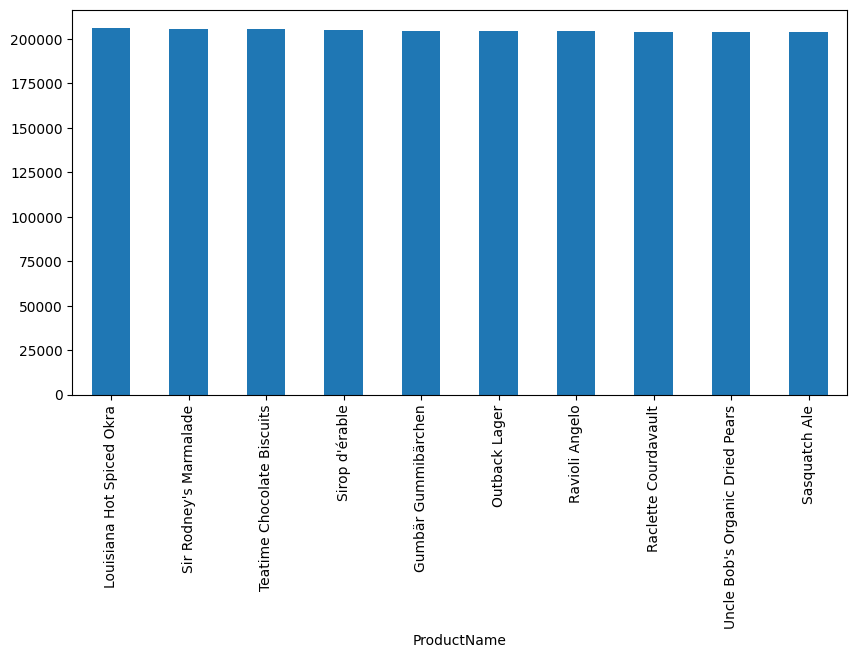

In [11]:
df1.plot(kind='bar', x='ProductName', y='TotalQuantitySold', figsize=(10,5), legend=False)

<Axes: xlabel='CompanyName'>

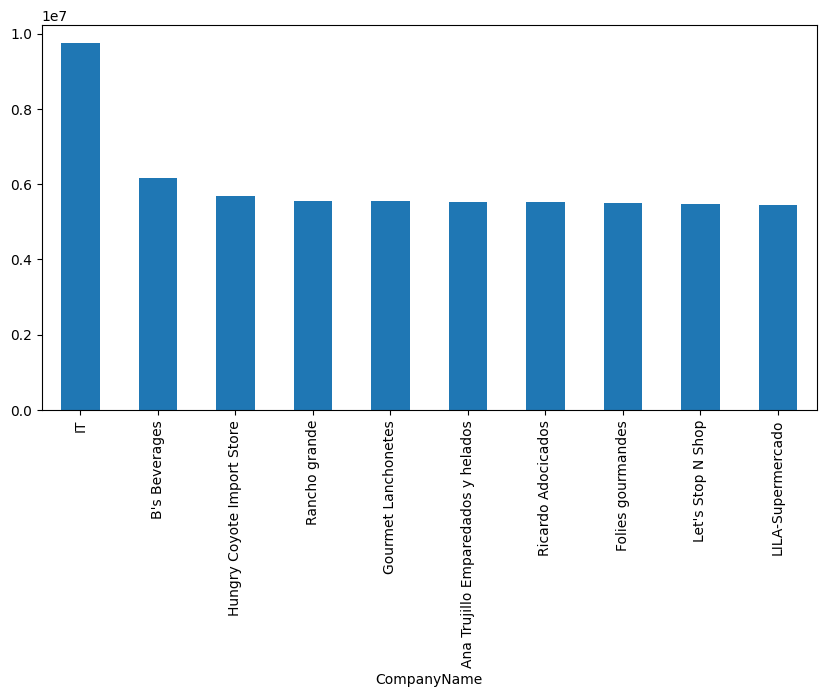

In [12]:
df2.plot(kind='bar', x='CompanyName', y='Revenue', figsize=(10,5), legend=False)

<Axes: xlabel='Month'>

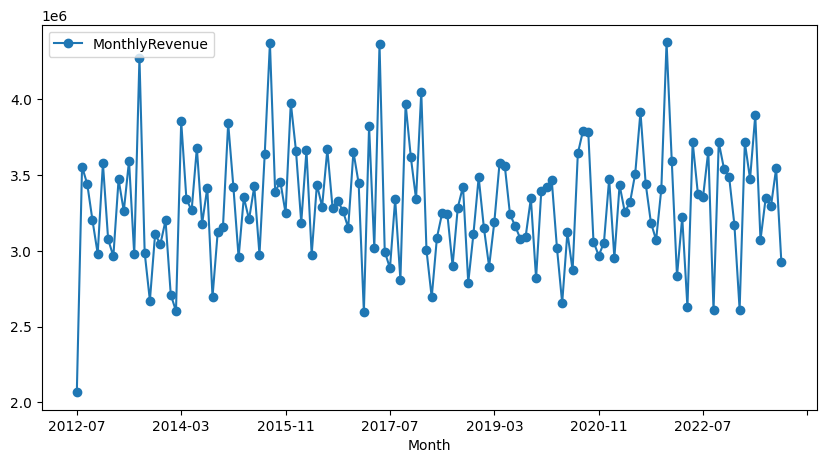

In [13]:
df3.plot(kind='line', x='Month', y='MonthlyRevenue', figsize=(10,5), marker='o')

<Axes: xlabel='CategoryName'>

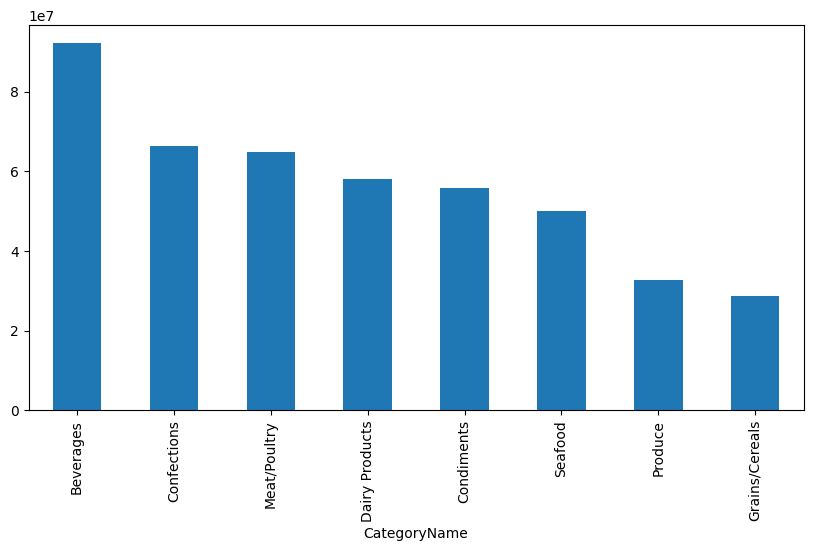

In [14]:
df4.plot(kind='bar', x='CategoryName', y='Revenue', figsize=(10,5), legend=False)

In [15]:
df5.describe()

,NumberOfOrders
count,10.000000
mean,213.800000
std,42.824707
min,195.000000
25%,197.250000
50%,201.000000
75%,203.000000
max,335.000000


## Key Business Insights

1. **Product sales are remarkably even at the top.** The top 10 products all sold within a narrow band of ~203,000–206,000 units (Louisiana Hot Spiced Okra leads at 206,213), showing no single "hero product" dominates, demand is spread broadly across the catalog rather than concentrated in one bestseller.

2. **Revenue is heavily concentrated among a small set of customers.** The top customer generated over $9.7M in revenue, roughly 58% more than the second-highest customer (B's Beverages at ~$6.15M), indicating the business relies significantly on a handful of major accounts.

3. **Sales have grown substantially over time.** Monthly revenue rose from around $2.07M in mid-2012 to a fairly stable $3–3.5M range by 2023, showing steady long-term growth with the business roughly 50%+ larger by revenue in its later years compared to its early months.

4. **Beverages is the standout category.** Beverages generated ~$92.2M in revenue, well ahead of the next category (Confections at ~$66.3M), nearly 39% higher, making it the clear priority category for inventory and marketing focus.

5. **High-value customers also order most frequently**, but not perfectly in sync. The top customer by order count (335 orders) also topped revenue, but customers ranked #2–4 by order frequency don't fully match the top revenue ranks, suggesting some frequent, smaller-basket customers versus infrequent, high-value ones.